# Tutorial 08 — Design Optimizer

**Goal:** Design an Nb/Cu₀.₄₃Ni₀.₅‷ bilayer with Tc = 5 K.

This notebook walks through the full design workflow:

1. Visualise the Tc landscape over (d_S, d_F)
2. Use `optimize_design()` to find the optimal d_F
3. Compute parameter sensitivities with `sensitivity_at()`
4. Run `robust_optimize()` to trade off Tc accuracy vs. fabrication tolerance
5. Compare standard and robust designs

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import supermag

supermag.apply_theme("publication")

## 1. Material parameters

We pull Nb (superconductor) and Cu₀.₄₃Ni₀.₅‷ (weak ferromagnet)
from the built-in database.  We use a clean interface
(γ = 0.20, γ_B = 0) in the thin-S limit, which gives a Tc
landscape with a clear minimum.

In [2]:
nb   = supermag.get_material("Nb")
cuni = supermag.get_material("Cu0.43Ni0.57")

# Clean interface parameters for demonstration
gamma   = 0.20
gamma_B = 0.0
model   = "thin_s"

print(f"Nb:   Tc = {nb['Tc']} K,  \u03be_S = {nb['xi_S']} nm")
print(f"CuNi: E_ex = {cuni['E_ex']} meV,  \u03be_F = {cuni['xi_F']} nm")
print(f"Interface: \u03b3 = {gamma},  \u03b3_B = {gamma_B}")

Nb:   Tc = 9.2 K,  ξ_S = 38.0 nm
CuNi: E_ex = 11.2 meV,  ξ_F = 4.2 nm
Interface: γ = 0.2,  γ_B = 0.0


## 2. Tc landscape

Compute Tc over a 2-D grid of (d_S, d_F) using `tc_phase_diagram`.
The contour at Tc = 5 K is our target — any (d_S, d_F) on that line is
a valid design.

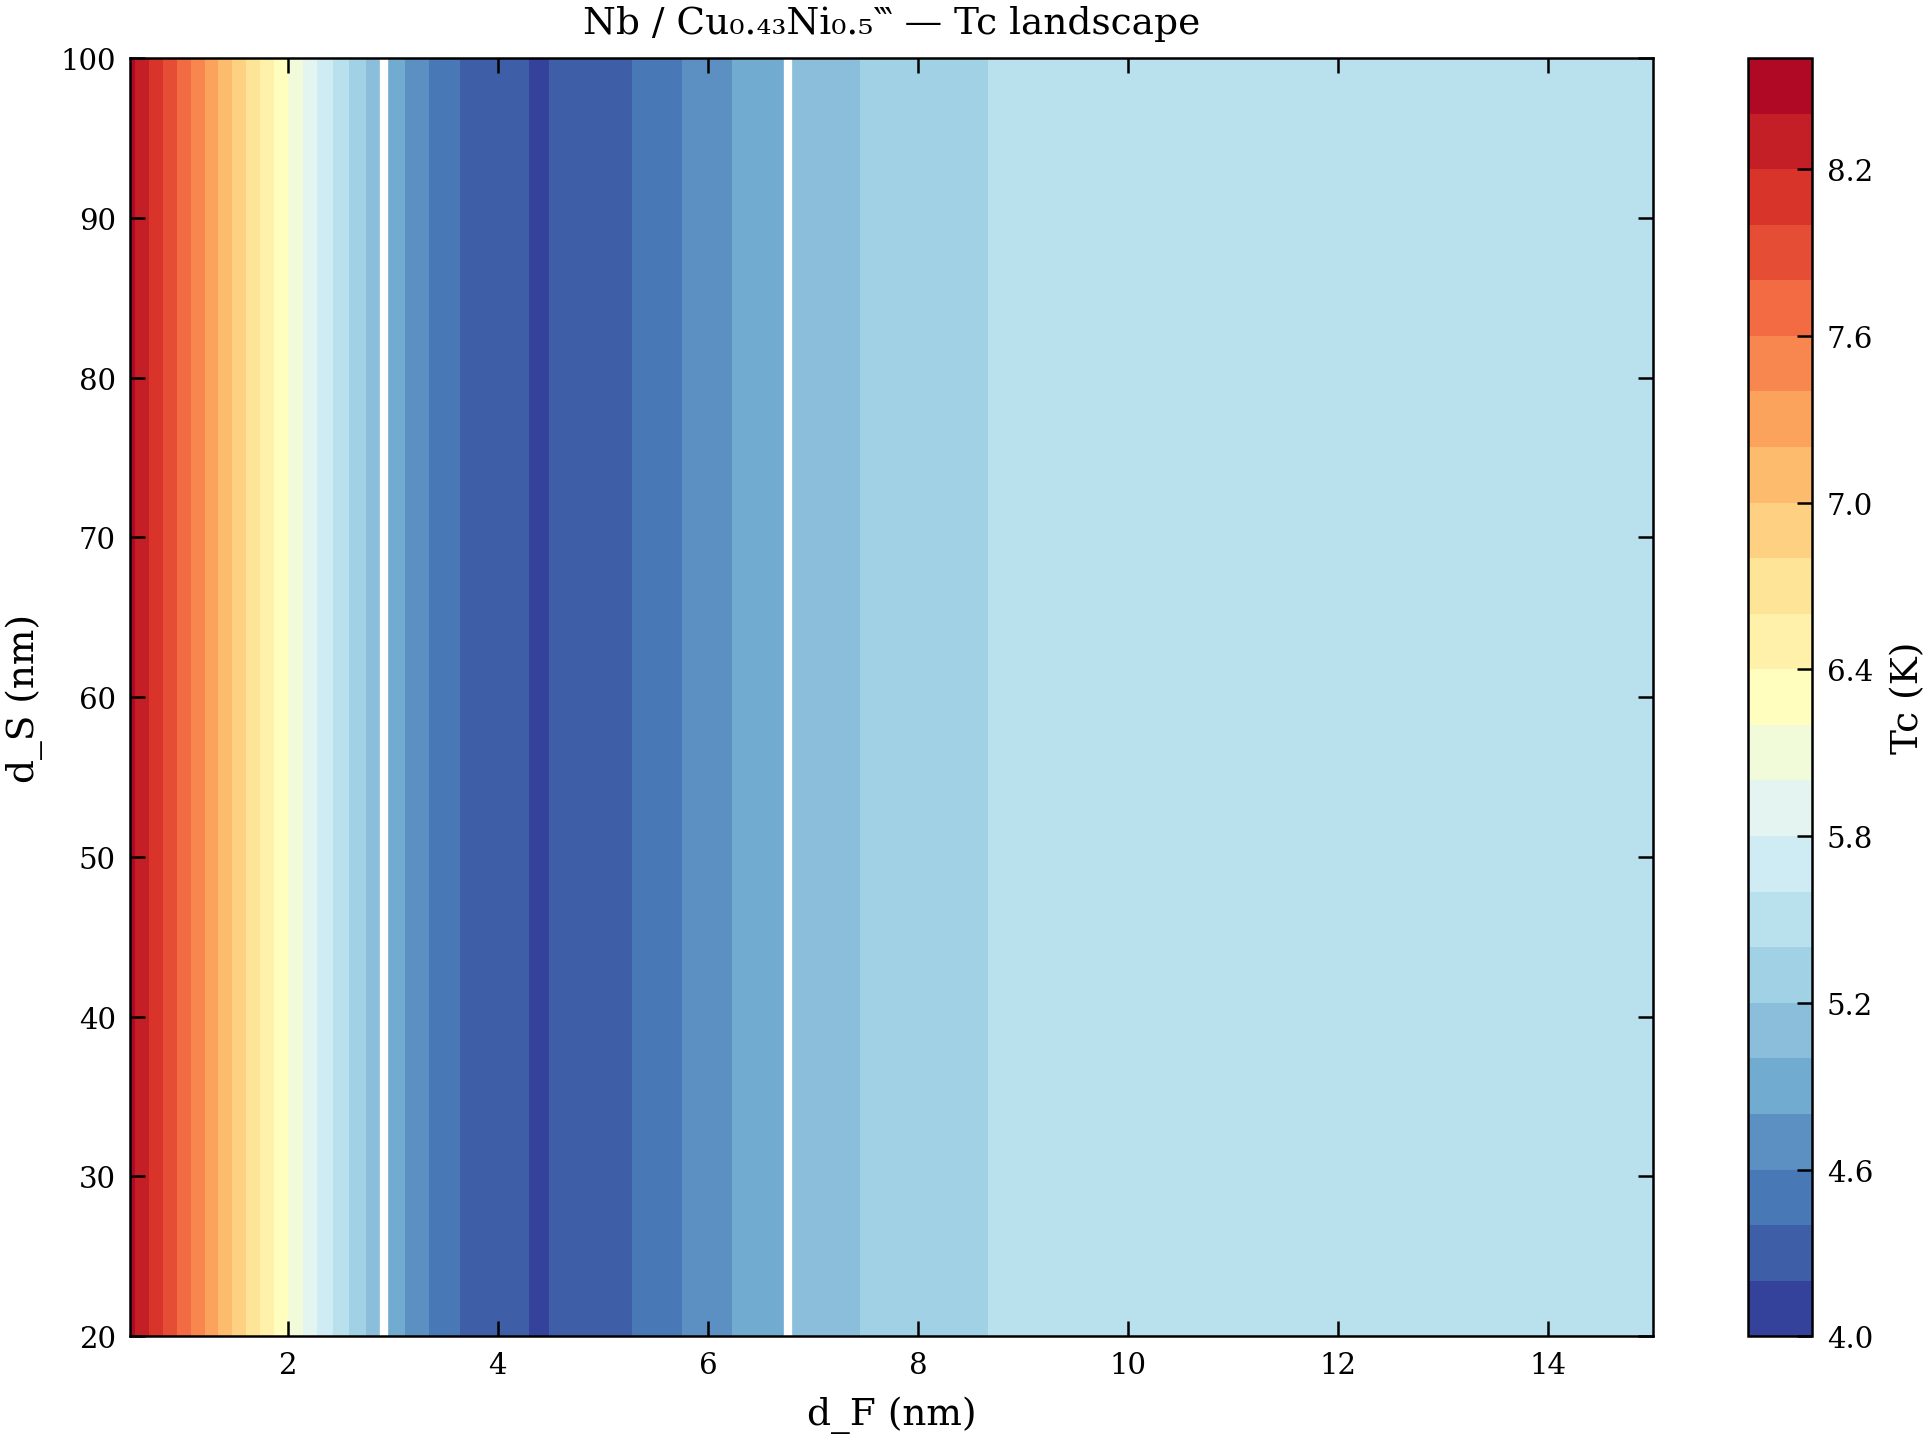

In [3]:
d_S_range = np.linspace(20, 100, 60)
d_F_range = np.linspace(0.5, 15, 60)

landscape = supermag.tc_phase_diagram(
    "d_S", d_S_range,
    "d_F", d_F_range,
    Tc0=nb["Tc"], xi_S=nb["xi_S"], xi_F=cuni["xi_F"],
    E_ex=cuni["E_ex"], D_F=cuni["D_F"],
    gamma=gamma, gamma_B=gamma_B,
    model=model,
)

Tc_map = landscape["Tc"]

fig, ax = plt.subplots(figsize=(7, 5))
cf = ax.contourf(d_F_range, d_S_range, Tc_map, levels=25, cmap="RdYlBu_r")
ax.contour(d_F_range, d_S_range, Tc_map, levels=[5.0],
           colors="white", linewidths=2)
fig.colorbar(cf, ax=ax, label="Tc (K)")
ax.set_xlabel("d_F (nm)")
ax.set_ylabel("d_S (nm)")
ax.set_title("Nb / Cu\u2080.\u2084\u2083Ni\u2080.\u2085\u2037 \u2014 Tc landscape")
plt.tight_layout()

## 3. Single-objective optimisation

Fix d_S = 50 nm and let the optimiser find d_F that gives Tc = 5 K.

In [4]:
result = supermag.optimize_design(
    Tc0=nb["Tc"], d_S=50.0,
    xi_S=nb["xi_S"], xi_F=cuni["xi_F"], E_ex=cuni["E_ex"],
    gamma=gamma, gamma_B=gamma_B, D_F=cuni["D_F"],
    model=model,
    Tc_target=5.0,
    vary_d_F=(0.5, 15),
    max_total_thickness=100,
)

print(f"Optimal d_F = {result['d_F']:.2f} nm")
print(f"Achieved Tc  = {result['Tc']:.4f} K")
print(f"Evaluations  = {result['evaluations']}")

Optimal d_F = 6.76 nm
Achieved Tc  = 5.0000 K
Evaluations  = 40


## 4. Sensitivity analysis

How much does Tc change if d_F, d_S, or \u03b3 drifts by 1 %?

> **Note:** In the thin-S model, Tc is independent of d_S by
> construction, so \u2202Tc/\u2202d_S = 0.

In [5]:
sens = supermag.sensitivity_at(
    Tc0=nb["Tc"], d_S=50.0, d_F=result["d_F"],
    xi_S=nb["xi_S"], xi_F=cuni["xi_F"], E_ex=cuni["E_ex"],
    gamma=gamma, gamma_B=gamma_B, D_F=cuni["D_F"],
    model=model,
)

print(f"\u2202Tc/\u2202d_F   = {sens['dTc_ddF']:.4f}  K/nm")
print(f"\u2202Tc/\u2202d_S   = {sens['dTc_ddS']:.4f}  K/nm")
print(f"\u2202Tc/\u2202\u03b3     = {sens['dTc_dgamma']:.4f}  K/unit")

∂Tc/∂d_F   = 0.3430  K/nm
∂Tc/∂d_S   = 0.0000  K/nm
∂Tc/∂γ     = -29.4843  K/unit


## 5. Sensitivity bar chart

Normalise the partials by typical fabrication tolerances to see which
parameter matters most.

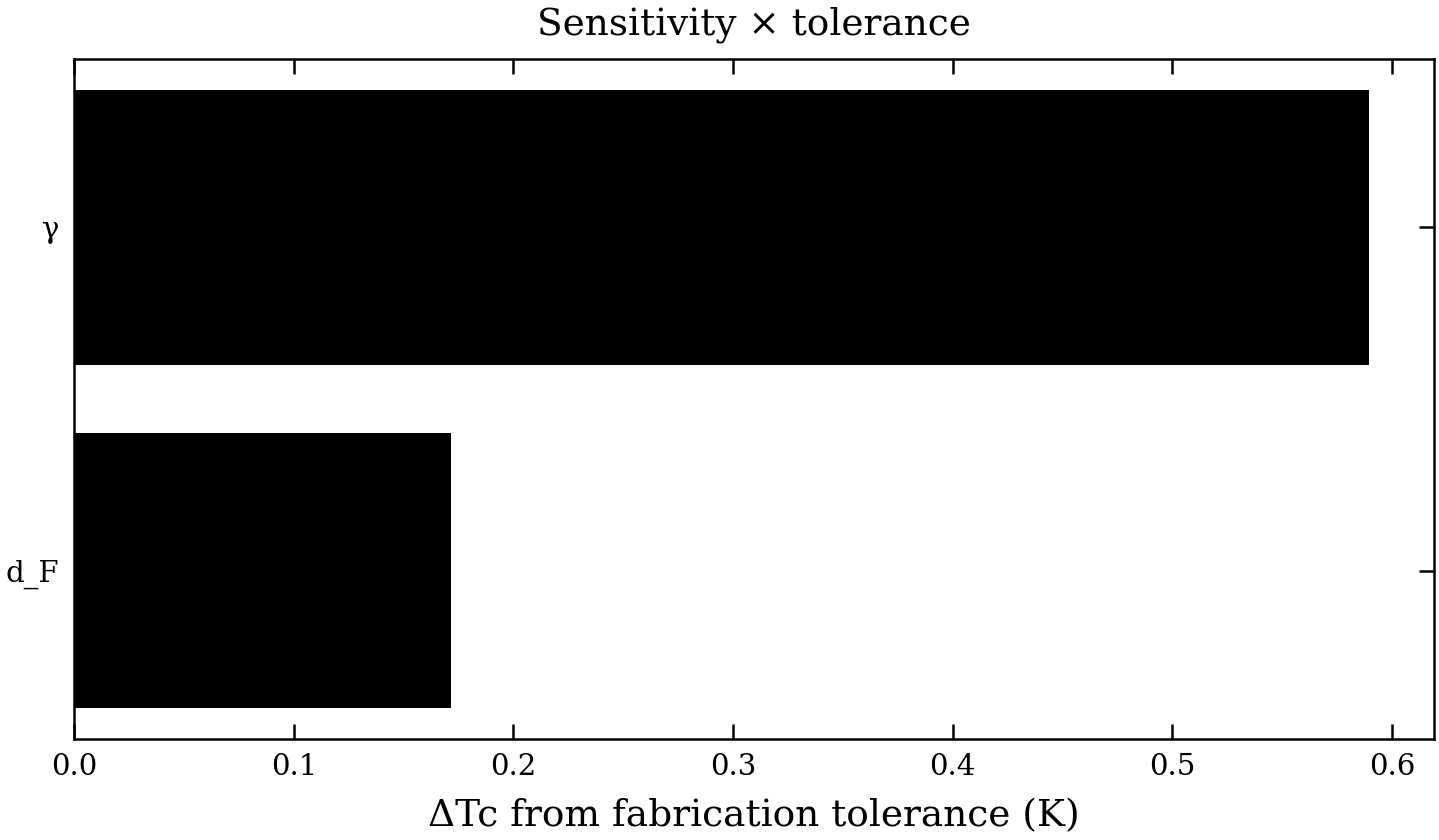

In [6]:
# Typical fabrication tolerances
tol_d_F   = 0.5   # nm
tol_gamma = 0.02  # dimensionless

dTc = {
    "d_F":   abs(sens["dTc_ddF"])   * tol_d_F,
    "\u03b3":     abs(sens["dTc_dgamma"]) * tol_gamma,
}

fig, ax = plt.subplots(figsize=(5, 3))
ax.barh(list(dTc.keys()), list(dTc.values()))
ax.set_xlabel("\u0394Tc from fabrication tolerance (K)")
ax.set_title("Sensitivity \u00d7 tolerance")
plt.tight_layout()

## 6. Robust optimisation

Now re-optimise with a penalty for sensitivity.  The robust optimiser
may move d_F to a region where Tc is slightly off-target but less
sensitive to fabrication errors.

In [7]:
robust = supermag.robust_optimize(
    Tc0=nb["Tc"], d_S=50.0,
    xi_S=nb["xi_S"], xi_F=cuni["xi_F"], E_ex=cuni["E_ex"],
    gamma=gamma, gamma_B=gamma_B, D_F=cuni["D_F"],
    model=model,
    Tc_target=5.0,
    vary_d_F=(0.5, 15),
    max_total_thickness=100,
    tolerances={"d_F": 0.5, "gamma": 0.02},
    robustness_weight=0.5,
)

print(f"Robust d_F   = {robust['d_F']:.2f} nm")
print(f"Robust Tc    = {robust['Tc']:.4f} K")
print(f"Evaluations  = {robust['evaluations']}")
print(f"\u2202Tc/\u2202d_F     = {robust['sensitivity']['dTc_ddF']:.4f} K/nm")

Robust d_F   = 7.10 nm
Robust Tc    = 5.1105 K
Evaluations  = 42
∂Tc/∂d_F     = 0.2913 K/nm


## 7. Design comparison

Side-by-side comparison of the standard and robust solutions,
overlaid on the Tc(d_F) curve.

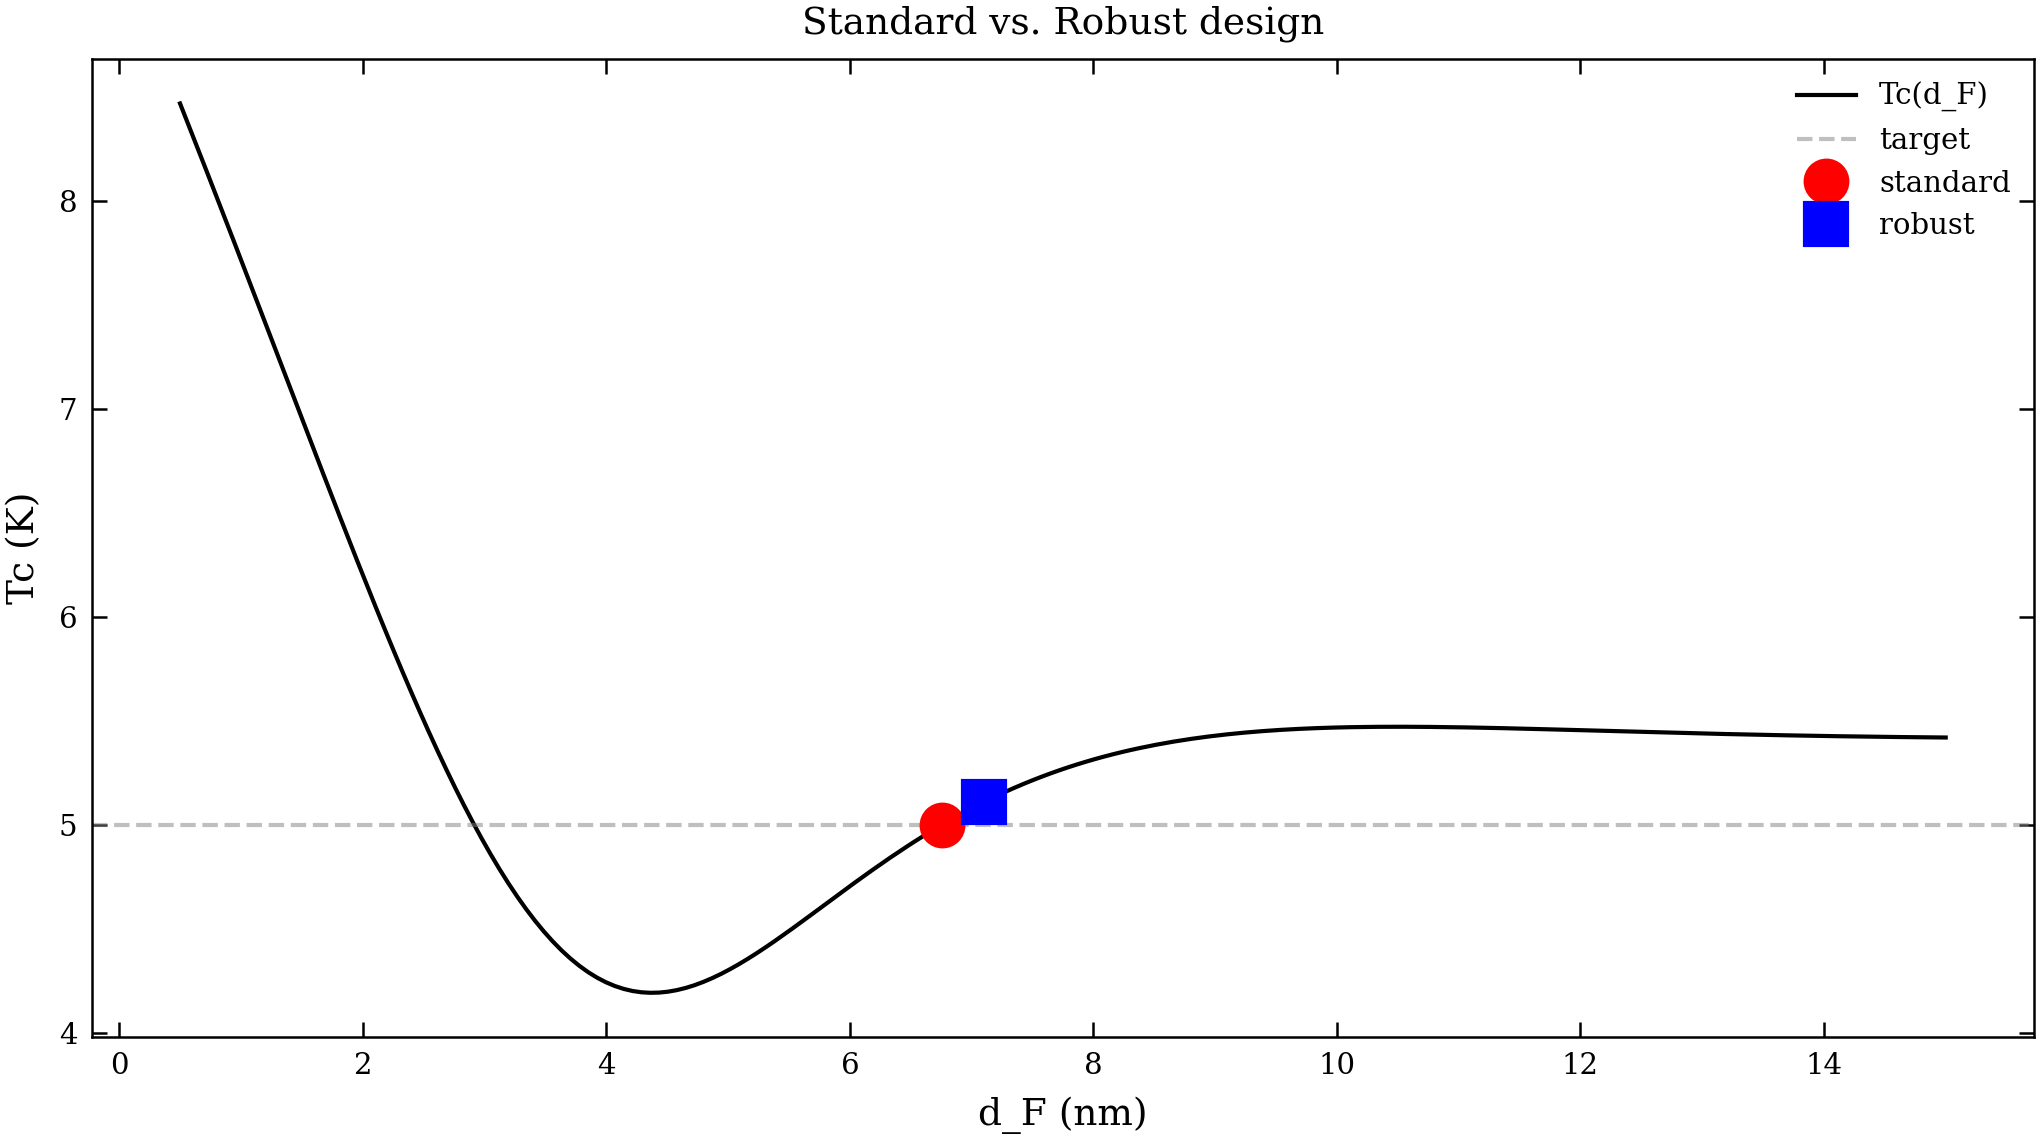

In [8]:
d_F_sweep = np.linspace(0.5, 15, 200)
Tc_sweep = supermag.critical_temperature(
    Tc0=nb["Tc"], d_S=50.0, d_F_array=d_F_sweep,
    E_ex=cuni["E_ex"], xi_S=nb["xi_S"], xi_F=cuni["xi_F"],
    gamma=gamma, gamma_B=gamma_B, D_F=cuni["D_F"],
    model=model,
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(d_F_sweep, Tc_sweep, "k-", label="Tc(d_F)")
ax.axhline(5.0, ls="--", color="gray", alpha=0.5, label="target")
ax.plot(result["d_F"], result["Tc"], "ro", ms=10, label="standard")
ax.plot(robust["d_F"], robust["Tc"], "bs", ms=10, label="robust")
ax.set_xlabel("d_F (nm)")
ax.set_ylabel("Tc (K)")
ax.legend()
ax.set_title("Standard vs. Robust design")
plt.tight_layout()

## 8. Multi-parameter optimisation

Vary both d_F and \u03b3 simultaneously to hit Tc = 5 K.

In [9]:
multi = supermag.optimize_design(
    Tc0=nb["Tc"], d_S=50.0,
    xi_S=nb["xi_S"], xi_F=cuni["xi_F"], E_ex=cuni["E_ex"],
    gamma=gamma, gamma_B=gamma_B, D_F=cuni["D_F"],
    model=model,
    Tc_target=5.0,
    vary_d_F=(0.5, 15),
    vary_gamma=(0.05, 0.50),
    max_total_thickness=100,
)

print(f"d_F = {multi['d_F']:.2f} nm,  \u03b3 = {multi['gamma']:.4f}")
print(f"Tc  = {multi['Tc']:.4f} K")

d_F = 8.94 nm,  γ = 0.2160
Tc  = 5.0000 K


## 9. Sensitivity heatmap

Overlay the optimal designs on the Tc landscape from Section 2.

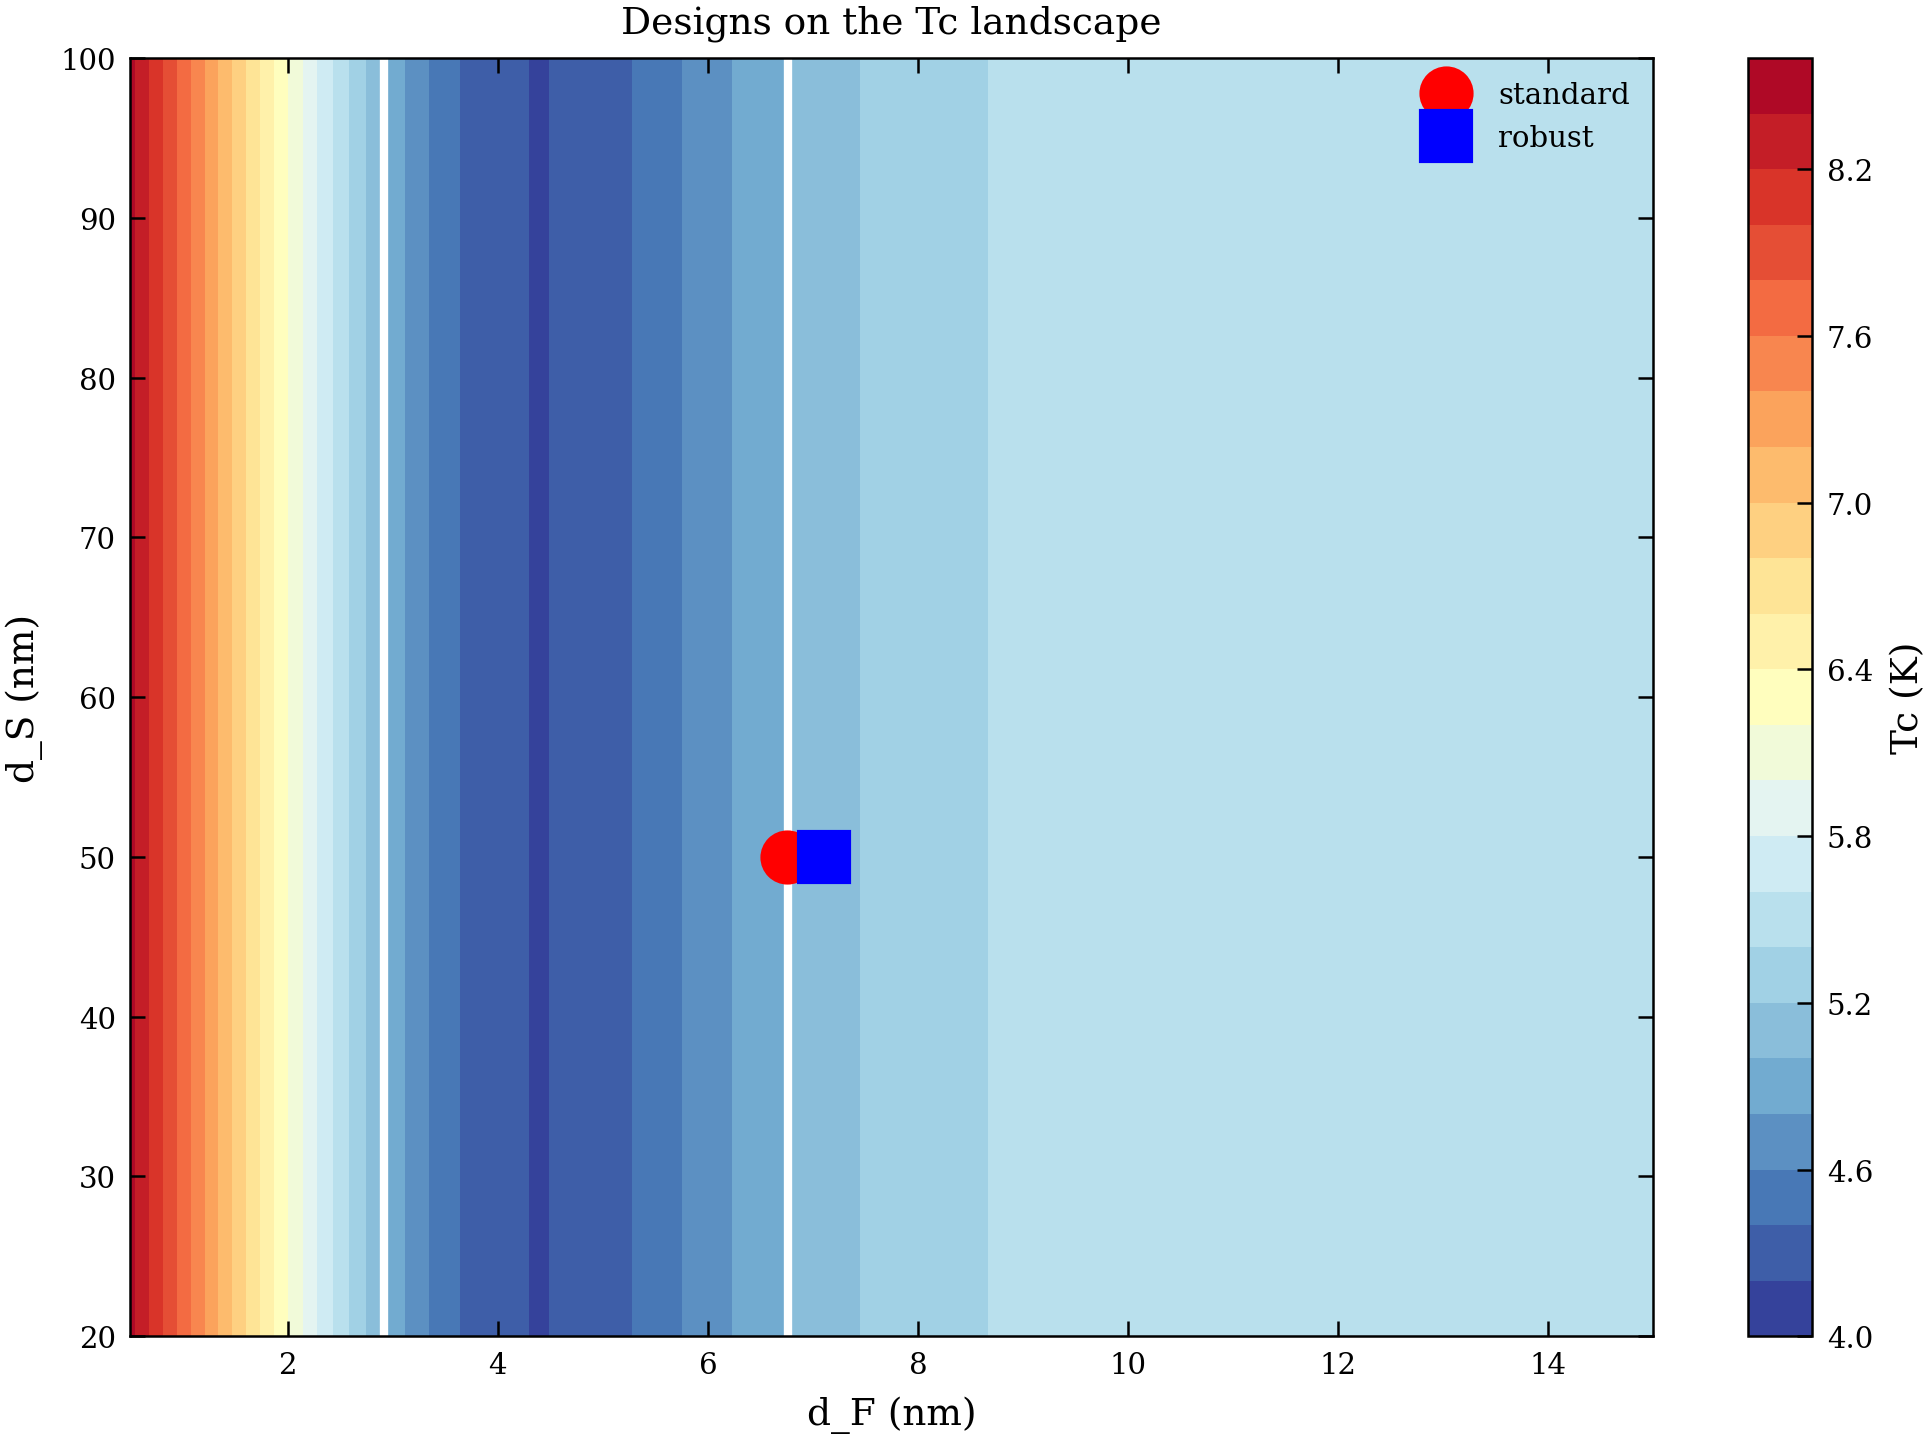

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
cf = ax.contourf(d_F_range, d_S_range, Tc_map, levels=25, cmap="RdYlBu_r")
ax.contour(d_F_range, d_S_range, Tc_map, levels=[5.0],
           colors="white", linewidths=2)
fig.colorbar(cf, ax=ax, label="Tc (K)")

# Plot designs
ax.plot(result["d_F"], 50.0, "ro", ms=12, label="standard", zorder=5)
ax.plot(robust["d_F"], 50.0, "bs", ms=12, label="robust", zorder=5)

ax.set_xlabel("d_F (nm)")
ax.set_ylabel("d_S (nm)")
ax.legend(loc="upper right")
ax.set_title("Designs on the Tc landscape")
plt.tight_layout()

## Summary

| Design | d_F (nm) | Tc (K) | Method |
|--------|----------|--------|--------|
| Standard | `result['d_F']` | `result['Tc']` | Nelder-Mead, fixed d_S |
| Robust | `robust['d_F']` | `robust['Tc']` | Sensitivity-penalised |
| Multi | `multi['d_F']` | `multi['Tc']` | Nelder-Mead, d_F + \u03b3 free |

The robust design sacrifices a small amount of Tc accuracy for lower
sensitivity to fabrication variations \u2014 a practical trade-off for
real sputtering systems.